# 📉 기술적 지표 분석 및 종목 스크리닝

**전제:** `01_data_collection.ipynb` 실행 완료 후 실행

분석 내용:
- RSI / MACD / 볼린저밴드 / 이동평균 계산 및 시각화
- 전 종목 자동 스크리닝: 매수/매도 신호 종목 추출
- 스크리닝 결과 CSV 저장

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
from tqdm import tqdm

from src.data_collector import get_stock_list, load_stock
from src.technical_indicators import add_all_indicators, generate_signals

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
print('준비 완료!')

준비 완료!


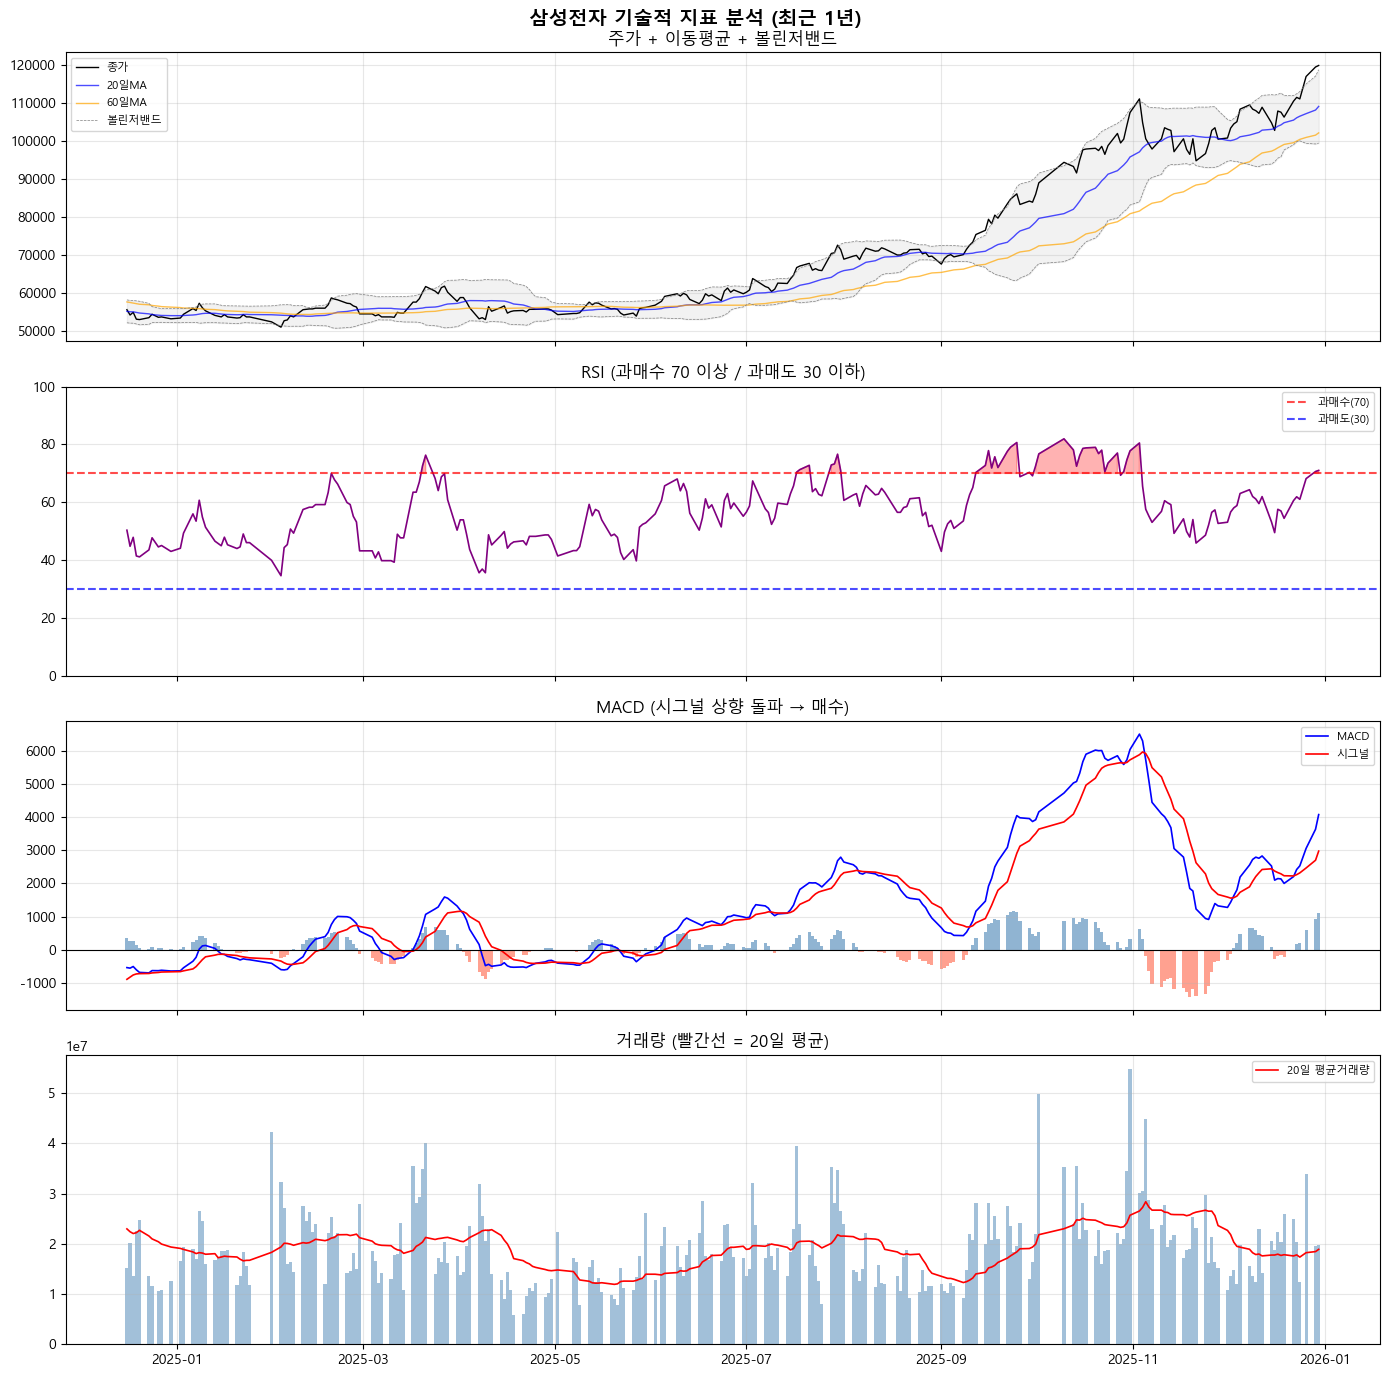

In [2]:
# ─────────────────────────────────────────
# 1단계: 삼성전자 기술적 지표 시각화
# ─────────────────────────────────────────
samsung = load_stock('005930')
samsung = add_all_indicators(samsung)
df = samsung.tail(252).copy()  # 최근 1년

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle('삼성전자 기술적 지표 분석 (최근 1년)', fontsize=14, fontweight='bold')

# 주가 + 이동평균 + 볼린저밴드
axes[0].plot(df.index, df['Close'], label='종가', color='black', linewidth=1)
axes[0].plot(df.index, df['MA_20'], label='20일MA', color='blue', linewidth=1, alpha=0.7)
axes[0].plot(df.index, df['MA_60'], label='60일MA', color='orange', linewidth=1, alpha=0.7)
axes[0].fill_between(df.index, df['BB_Upper'], df['BB_Lower'], alpha=0.1, color='gray')
axes[0].plot(df.index, df['BB_Upper'], color='gray', linewidth=0.5, linestyle='--', label='볼린저밴드')
axes[0].plot(df.index, df['BB_Lower'], color='gray', linewidth=0.5, linestyle='--')
axes[0].set_title('주가 + 이동평균 + 볼린저밴드')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(df.index, df['RSI'], color='purple', linewidth=1.2)
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.7, label='과매수(70)')
axes[1].axhline(y=30, color='blue', linestyle='--', alpha=0.7, label='과매도(30)')
axes[1].fill_between(df.index, df['RSI'], 70, where=(df['RSI'] > 70), alpha=0.3, color='red')
axes[1].fill_between(df.index, df['RSI'], 30, where=(df['RSI'] < 30), alpha=0.3, color='blue')
axes[1].set_ylim(0, 100)
axes[1].set_title('RSI (과매수 70 이상 / 과매도 30 이하)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# MACD
axes[2].plot(df.index, df['MACD'], label='MACD', color='blue', linewidth=1.2)
axes[2].plot(df.index, df['MACD_Signal'], label='시그널', color='red', linewidth=1.2)
hist_colors = ['tomato' if v < 0 else 'steelblue' for v in df['MACD_Hist']]
axes[2].bar(df.index, df['MACD_Hist'], color=hist_colors, alpha=0.6, width=1)
axes[2].axhline(y=0, color='black', linewidth=0.8)
axes[2].set_title('MACD (시그널 상향 돌파 → 매수)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# 거래량
axes[3].bar(df.index, df['Volume'], color='steelblue', alpha=0.5, width=1)
axes[3].plot(df.index, df['Volume_MA'], color='red', linewidth=1.2, label='20일 평균거래량')
axes[3].set_title('거래량 (빨간선 = 20일 평균)')
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# ─────────────────────────────────────────
# 2단계: 전 종목 스크리닝
# ─────────────────────────────────────────
stock_list = get_stock_list()
name_map = stock_list.set_index('Code')['Name'].to_dict() if 'Name' in stock_list.columns else {}
market_map = stock_list.set_index('Code')['Market'].to_dict() if 'Market' in stock_list.columns else {}

price_dir = '../data/prices'
files = [f for f in os.listdir(price_dir) if f.endswith('.parquet')]

screening_results = []

print(f'전 종목 스크리닝 시작: {len(files)}개 종목...')
for fname in tqdm(files, desc='스크리닝'):
    code = fname.replace('.parquet', '')
    df = load_stock(code)
    if df is None or len(df) < 120:
        continue
    try:
        df = add_all_indicators(df)
        signals = generate_signals(df)
        last = df.iloc[-1]
        last_sig = signals.iloc[-1]

        screening_results.append({
            '종목코드': code,
            '종목명': name_map.get(code, code),
            '시장': market_map.get(code, ''),
            '현재가': int(last['Close']),
            'RSI': round(last['RSI'], 1) if pd.notna(last['RSI']) else None,
            'MACD히스토': round(last['MACD_Hist'], 2) if pd.notna(last['MACD_Hist']) else None,
            '볼린저위치': round(last['BB_Pct'], 3) if pd.notna(last['BB_Pct']) else None,
            '거래량배율': round(last['Volume_Ratio'], 2) if pd.notna(last['Volume_Ratio']) else None,
            '종합점수': int(last_sig['Total_Score']),
            '신호': int(last_sig['Final_Signal']),
        })
    except Exception:
        pass

screen_df = pd.DataFrame(screening_results)
print(f'완료: {len(screen_df)}개 종목 분석')

캐시에서 로드: 2770개 종목
전 종목 스크리닝 시작: 2731개 종목...


스크리닝: 100%|████████████████████████████████████████████████████████████████████| 2731/2731 [00:43<00:00, 62.31it/s]

완료: 2687개 종목 분석


In [4]:
# 스크리닝 결과 출력
buy_df = screen_df[screen_df['신호'] == 1].sort_values('종합점수', ascending=False)
sell_df = screen_df[screen_df['신호'] == -1].sort_values('종합점수')

print(f'매수 신호 종목: {len(buy_df)}개')
print(buy_df[['종목코드','종목명','시장','현재가','RSI','볼린저위치','종합점수']].head(20).to_string(index=False))

print(f'\n매도 신호 종목: {len(sell_df)}개')
print(sell_df[['종목코드','종목명','시장','현재가','RSI','볼린저위치','종합점수']].head(10).to_string(index=False))

매수 신호 종목: 58개
  종목코드      종목명     시장   현재가  RSI  볼린저위치  종합점수
000040    KR모터스  KOSPI   451 28.7 -0.216     2
000087 하이트진로2우B  KOSPI 15120 28.2 -0.276     2
001210     금호전기  KOSPI   521 18.2 -0.112     2
002710    TCC스틸  KOSPI 13920 29.4  0.016     2
003220     대원제약  KOSPI 11950 28.9 -0.031     2
004450     삼화왕관  KOSPI 29300 28.7 -0.106     2
004650    창해에탄올 KOSDAQ  9820 29.3 -0.218     2
005420    코스모화학  KOSPI 14350 29.2  0.012     2
006740   블루산업개발  KOSPI   789 10.3 -0.233     2
008370       원풍 KOSDAQ  4845 29.0 -0.208     2
008730     율촌화학  KOSPI 25800 25.1 -0.010     2
008775    호텔신라우  KOSPI 36950 23.9 -0.101     2
012160       영흥  KOSPI   489 27.1 -0.144     2
012750      에스원  KOSPI 72100 38.3 -0.084     2
014130   한익스프레스  KOSPI  3045 21.5 -0.003     2
016100  리더스코스메틱 KOSDAQ  1933 23.7 -0.043     2
018250     애경산업  KOSPI 13140 29.2 -0.137     2
020560   아시아나항공  KOSPI  7860 28.0 -0.014     2
025000   KPX케미칼  KOSPI 46700 21.1 -0.121     2
026890 스틱인베스트먼트  KOSPI  9380 29.6 -0.038     2

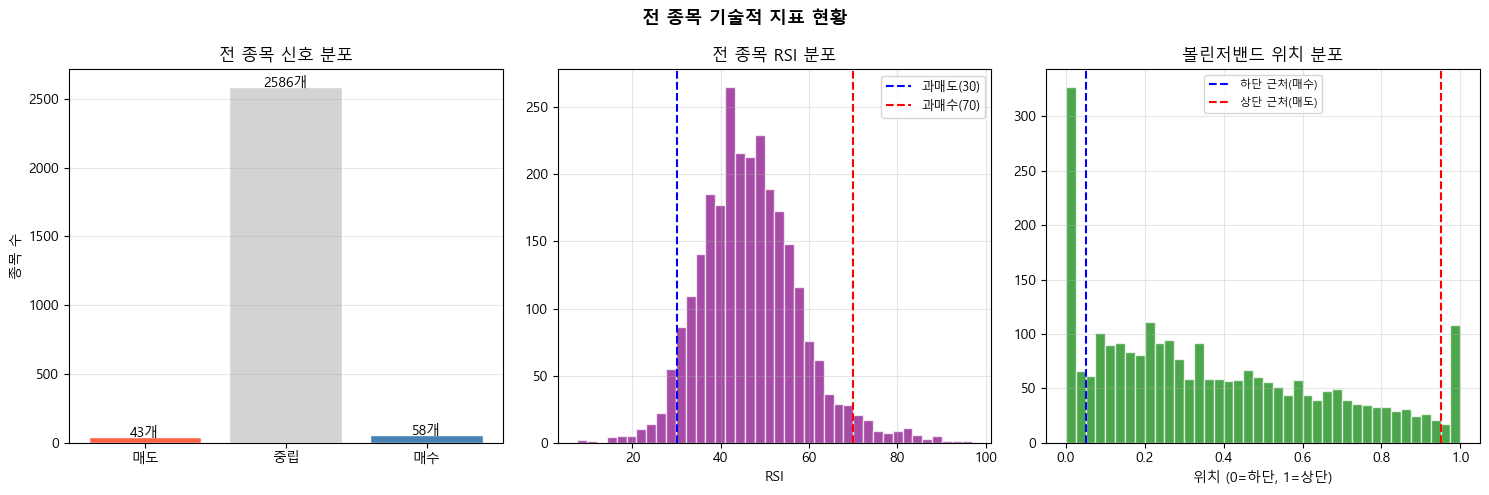


스크리닝 결과 저장 완료! → data/stock_list/screening_result.csv
다음: 04_lstm_prediction.ipynb


In [5]:
# 스크리닝 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 신호 분포
sig_counts = screen_df['신호'].value_counts().sort_index()
labels = {-1: '매도', 0: '중립', 1: '매수'}
clrs = {-1: 'tomato', 0: 'lightgray', 1: 'steelblue'}
axes[0].bar([labels[k] for k in sig_counts.index],
            sig_counts.values,
            color=[clrs[k] for k in sig_counts.index], edgecolor='white')
for i, v in enumerate(sig_counts.values):
    axes[0].text(i, v + 2, f'{v}개', ha='center', fontsize=10)
axes[0].set_title('전 종목 신호 분포')
axes[0].set_ylabel('종목 수')
axes[0].grid(True, alpha=0.3, axis='y')

# RSI 분포
axes[1].hist(screen_df['RSI'].dropna(), bins=40, color='purple', alpha=0.7, edgecolor='white')
axes[1].axvline(x=30, color='blue', linestyle='--', label='과매도(30)')
axes[1].axvline(x=70, color='red', linestyle='--', label='과매수(70)')
axes[1].set_title('전 종목 RSI 분포')
axes[1].set_xlabel('RSI')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 볼린저밴드 위치 분포
axes[2].hist(screen_df['볼린저위치'].dropna().clip(0, 1), bins=40,
             color='green', alpha=0.7, edgecolor='white')
axes[2].axvline(x=0.05, color='blue', linestyle='--', label='하단 근처(매수)')
axes[2].axvline(x=0.95, color='red', linestyle='--', label='상단 근처(매도)')
axes[2].set_title('볼린저밴드 위치 분포')
axes[2].set_xlabel('위치 (0=하단, 1=상단)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle('전 종목 기술적 지표 현황', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 저장
os.makedirs('../data/stock_list', exist_ok=True)
screen_df.to_csv('../data/stock_list/screening_result.csv', index=False, encoding='utf-8-sig')
print('\n스크리닝 결과 저장 완료! → data/stock_list/screening_result.csv')
print('다음: 04_lstm_prediction.ipynb')